In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
print(mnist.keys())    

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [2]:
X, y = mnist['data'], mnist['target']
print(X.shape)  #Zbiór danych zawiera 70000 obrazów, każdy jest opisany 784 cechami wynik: (70000, 784)
print(y.shape)

(70000, 784)
(70000,)


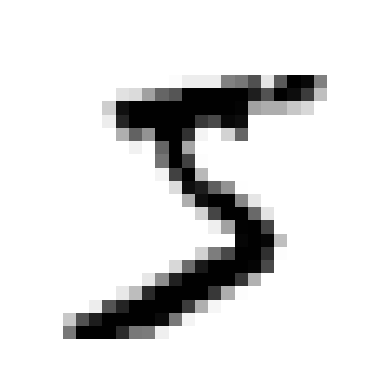

In [3]:
import matplotlib.pyplot as plt 

pierwszy = X.iloc[0].to_numpy() 
pierwszy_image = pierwszy.reshape(28, 28)

plt.imshow(pierwszy_image, cmap='binary')
plt.axis('off') #wyłączenie skali 
plt.show()

In [4]:
y[0]

'5'

In [5]:
import numpy as np
y = y.astype(np.uint8) #przekształcenie y na typ liczb całkowitych pod wprowadzenie do algorytmu uczenia maszynowego

In [6]:
X_train, X_test, Y_train, Y_test = X[:60000], X[60000:], y[:60000], y[60000:] 

In [7]:
y_train_5 = (Y_train == 5) #Wartość True dla 5 i False dla pozostałych cyfr 
y_test_5 = (Y_test == 5) 


In [8]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state = 42) #Ustawienie random_state pozwala na powtarzalne wyniki (może być to losowa liczba)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [9]:
sgd_clf.predict([pierwszy])

C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [10]:
#Metoda sprawdzania krzyżowego: funkcja cross_val_score()
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train, y_train_5, cv=2, scoring = 'accuracy') #cv odpowiada za podzielenie na x zbiorów, jeżeli cv = x. Scoring mowi jakim miernikiem ma być oceniany model, w tym wypadku dokładność = liczba poprawnych predykcji/ wszystkie 

array([0.95506667, 0.9524    ])

In [11]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self,X, y =None): #Każdy klasyfikator musi mieć metodę fit
        return self
    def predict(self,X):
        return np.zeros((len(X),1), dtype=bool) 
never5_clf = Never5Classifier()
cross_val_score(never5_clf, X_train, y_train_5, cv=3, scoring = 'accuracy')

array([0.91125, 0.90855, 0.90915])

In [12]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [13]:
from sklearn.metrics import confusion_matrix, roc_curve

confusion_matrix(y_train_5, y_train_pred)
#53892 Prawdziwie negatywne (niebędące 5)
#687 Fałszywie pozytywne (niewłaściwie uznane za 5)
#1891 Fałszywie negatywne (5 sklasyfikowane jako nie 5)
#3530 Prawdziwie pozytywne (5 prawidłowo sklasyfikowane jako 5).


array([[53892,   687],
       [ 1891,  3530]])

In [14]:
#Precyzja - dokładnośc pozytywnych prognoz 
from sklearn.metrics import precision_score
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [15]:
#Pełność - odsetek pozytywnych przykładów, które zostały prawidłowo rozpoznane przez klasyfikator 
from sklearn.metrics import recall_score
recall_score(y_train_5, y_train_pred)
#Prawidołowo rozpoznaje tylko 65% piątek 

0.6511713705958311

In [16]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [17]:
y_scores = sgd_clf.decision_function([pierwszy])
y_scores

C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([2164.22030239])

In [18]:
prog = 0 
y_pierwszy_pred = (y_scores > prog)

In [19]:
y_scores = cross_val_predict(sgd_clf,X_train, y_train_5, cv = 3, method = 'decision_function')
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

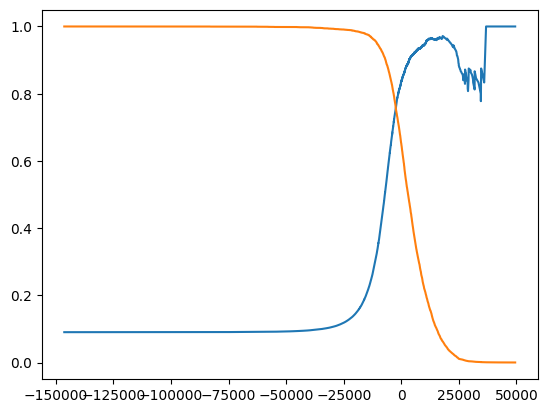

In [20]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], label='Precision')
    plt.plot(thresholds, recalls[:-1], label='Recall')
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()
    

In [21]:
prog_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [22]:
y_train_pred_90 = (y_scores > prog_90_precision)

In [23]:
precision_score(y_train_5, y_train_pred_90)

0.9

In [24]:
recall_score(y_train_5, y_train_pred_90)

0.47980077476480354

In [25]:
from sklearn.metrics import roc_curve
fpr, tpr, progi = roc_curve(y_train_5, y_scores)

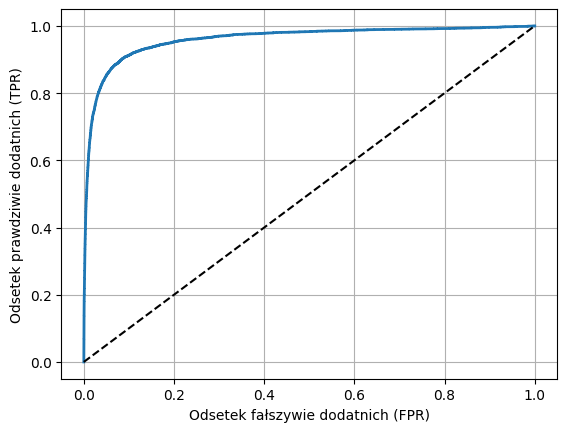

In [26]:
def plot_roc_curve(fpr, tpr, label= None):
    plt.plot(fpr,tpr,linewidth=2, label = label)
    plt.plot([0,1],[0,1],'k--') #przerywana przekątna 
    plt.xlabel("Odsetek fałszywie dodatnich (FPR)")
    plt.ylabel("Odsetek prawdziwie dodatnich (TPR)")
    plt.grid(True)
plot_roc_curve(fpr, tpr)
plt.show()


In [27]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [28]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method = 'predict_proba')
y_probas_forest

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       ...,
       [0.02, 0.98],
       [0.92, 0.08],
       [0.94, 0.06]], shape=(60000, 2))

In [29]:
from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(X_train, Y_train) #Strategia OVO(jeden przeciw jednemu), wytrenowanie 45 klasyfikatorów, oraz wybranie najlepszej
svm_clf.predict([pierwszy]) #model stosuje wiedzę i zgaduje etykiete 

C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([5], dtype=uint8)

In [30]:
pierwszy_score = svm_clf.decision_function([pierwszy])
pierwszy_score

C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [31]:
np.argmax(pierwszy_score)

np.int64(5)

In [32]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train, Y_train)
ovr_clf.predict([pierwszy])

C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature na

array([5], dtype=uint8)

In [33]:
sgd_clf.fit(X_train, Y_train)
sgd_clf.predict([pierwszy])

C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([3], dtype=uint8)

In [38]:
print(sgd_clf.decision_function([pierwszy]))

[[-31893.03095419 -19047.55566534  -9530.63950739   1823.73154031
  -22320.14822878  -1385.80478895 -26188.91070951 -16147.51323997
   -4604.35491274 -12050.767298  ]]


C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [35]:
cross_val_score(ovr_clf,X_train, Y_train, cv=3, scoring = 'accuracy')

array([0.97685, 0.9738 , 0.97495])

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, Y_train, cv = 3, scoring = 'accuracy')

C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

In [39]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, Y_train, cv = 3)
conf_mx = confusion_matrix(Y_train, y_train_pred)
conf_mx

C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\wikto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5573,    0,   23,    5,    8,   44,   36,    6,  227,    1],
       [   0, 6398,   37,   24,    4,   43,    4,    7,  214,   11],
       [  29,   25, 5220,   91,   73,   25,   68,   36,  380,   11],
       [  22,   17,  117, 5224,    2,  204,   27,   40,  405,   73],
       [  12,   14,   40,    9, 5181,   12,   34,   25,  351,  164],
       [  26,   15,   29,  165,   53, 4445,   74,   14,  541,   59],
       [  30,   15,   43,    3,   43,   96, 5551,    3,  133,    1],
       [  20,    9,   51,   29,   49,   12,    3, 5680,  200,  212],
       [  18,   64,   47,   89,    3,  124,   25,   10, 5426,   45],
       [  23,   18,   30,   65,  117,   37,    1,  179,  387, 5092]])

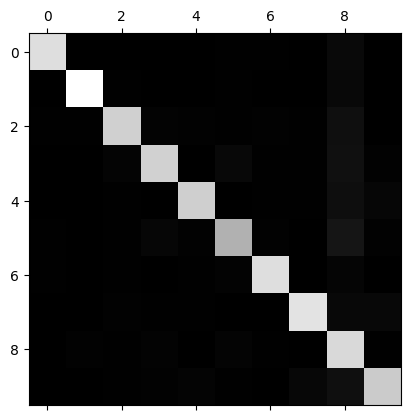

In [43]:
plt.matshow(conf_mx, cmap = plt.cm.gray)
plt.show()

In [44]:
row_sums = conf_mx.sum(axis = 1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

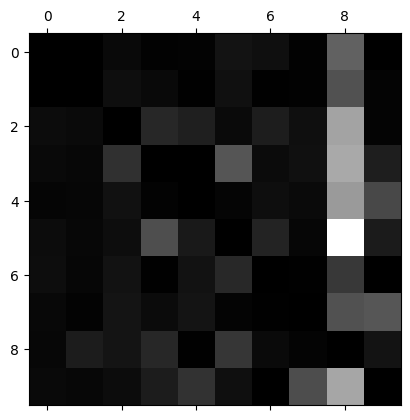

In [45]:
np.fill_diagonal(norm_conf_mx, 0) #uzupełnienie głównej przekątnej 0 
plt.matshow(norm_conf_mx, cmap = plt.cm.gray)
plt.show()